In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
df=pd.read_csv('TSLA.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   str    
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 132.3 KB


In [18]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [20]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["HL Range"]= (df["High"] - df["Low"])
df["SMA-5"]=df["Close"].rolling(5).mean()
df["SMA-10"]=df["Close"].rolling(10).mean()
df["SMA-20"]=df["Close"].rolling(20).mean()
df["SMA-50"]=df["Close"].rolling(50).mean()

In [9]:
df["Volume-5"]=df["Volume"].rolling(5).mean()
df["Volume-10"]=df["Volume"].rolling(10).mean()
df["Volume-30"]=df["Volume"].rolling(30).mean()

In [11]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

In [12]:
df["day_of_week"] = df["Date"].dt.dayofweek

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [13]:
df["Returns"] = df["Close"].pct_change()
df["Volatility_5"] = df["Returns"].rolling(5).std()
df["Volatility_10"] = df["Returns"].rolling(10).std()


In [14]:
corr_with_target = df.corr()["Adj Close"].sort_values(ascending=False)
print(corr_with_target)

Close            1.000000
Adj Close        1.000000
High             0.999640
Low              0.999447
Open             0.998886
SMA-5            0.997892
SMA-10           0.995207
SMA-20           0.989610
SMA-50           0.973085
Date             0.890294
Year             0.886089
HL Range         0.700342
Volume-30        0.664664
Volume-10        0.625032
Volume-5         0.585297
Volume           0.505169
Returns          0.032148
Month_cos        0.026844
dow_cos          0.004073
Month_sin       -0.001920
day_of_week     -0.003892
dow_sin         -0.003931
Month           -0.008383
Volatility_5    -0.141476
Volatility_10   -0.184097
Name: Adj Close, dtype: float64


In [15]:
df.dropna(inplace=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume,HL Range,SMA-5,SMA-10,...,Year,Month,Month_sin,Month_cos,day_of_week,dow_sin,dow_cos,Returns,Volatility_5,Volatility_10
49,2010-09-08,20.660000,20.950001,20.600000,20.900000,20.900000,288400,0.350001,20.800000,20.270000,...,2010,9,-1.000000,-1.836970e-16,2,0.974928,-0.222521,0.017527,0.028346,0.024368
50,2010-09-09,21.000000,21.049999,20.690001,20.709999,20.709999,376200,0.359998,20.852000,20.351000,...,2010,9,-1.000000,-1.836970e-16,3,0.433884,-0.900969,-0.009091,0.021389,0.022829
51,2010-09-10,20.750000,20.930000,19.760000,20.170000,20.170000,386600,1.170000,20.674000,20.393000,...,2010,9,-1.000000,-1.836970e-16,4,-0.433884,-0.900969,-0.026074,0.018016,0.024576
52,2010-09-13,20.889999,20.900000,20.500000,20.719999,20.719999,360800,0.400000,20.608000,20.495000,...,2010,9,-1.000000,-1.836970e-16,0,0.000000,1.000000,0.027268,0.024278,0.025696
53,2010-09-14,20.540001,21.600000,20.530001,21.120001,21.120001,654700,1.069999,20.724000,20.620000,...,2010,9,-1.000000,-1.836970e-16,1,0.781831,0.623490,0.019305,0.022464,0.026066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,18.729981,566.300012,545.911005,...,2020,1,0.500000,8.660254e-01,1,0.781831,0.623490,0.015913,0.022303,0.031282
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,22.369995,568.586011,550.218005,...,2020,1,0.500000,8.660254e-01,2,0.974928,-0.222521,0.024854,0.016733,0.031280
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,32.880005,582.308008,562.449005,...,2020,1,0.500000,8.660254e-01,3,0.433884,-0.900969,0.102962,0.047332,0.039299
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,20.479980,599.458008,576.157007,...,2020,1,0.500000,8.660254e-01,4,-0.433884,-0.900969,0.015231,0.043393,0.037826


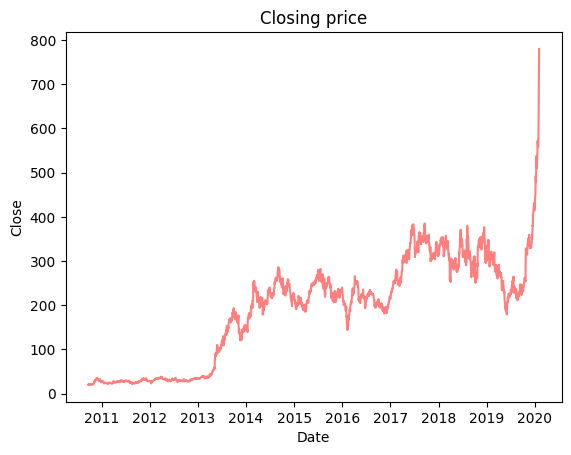

In [ ]:

plt.plot(df["Date"],df["Close"],color="red",alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Closing price")
plt.show()

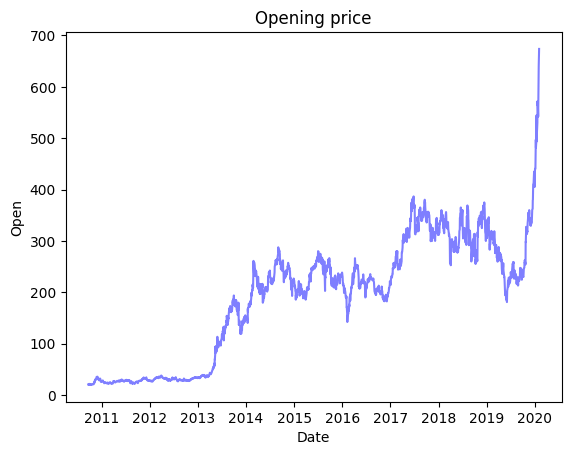

In [134]:
plt.plot(df["Date"],df["Open"],color="blue",alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Open")
plt.title("Opening price")
plt.show()

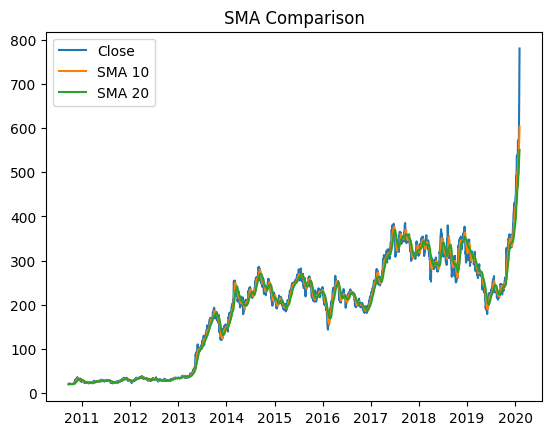

In [135]:
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA-10"], label="SMA 10")
plt.plot(df["Date"], df["SMA-20"], label="SMA 20")
plt.title("SMA Comparison")
plt.legend()
plt.show()

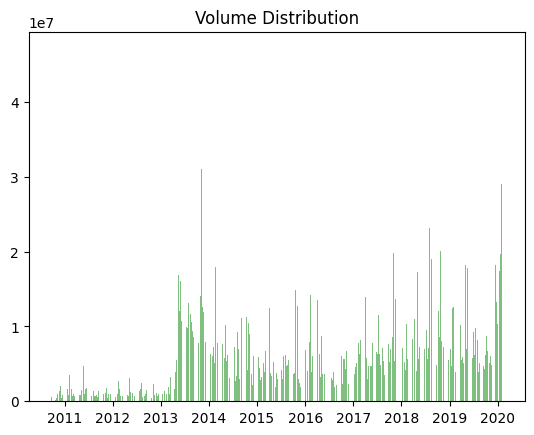

In [136]:
plt.bar(df["Date"], df["Volume"], alpha=0.5,color="green")
plt.title("Volume Distribution")
plt.show()

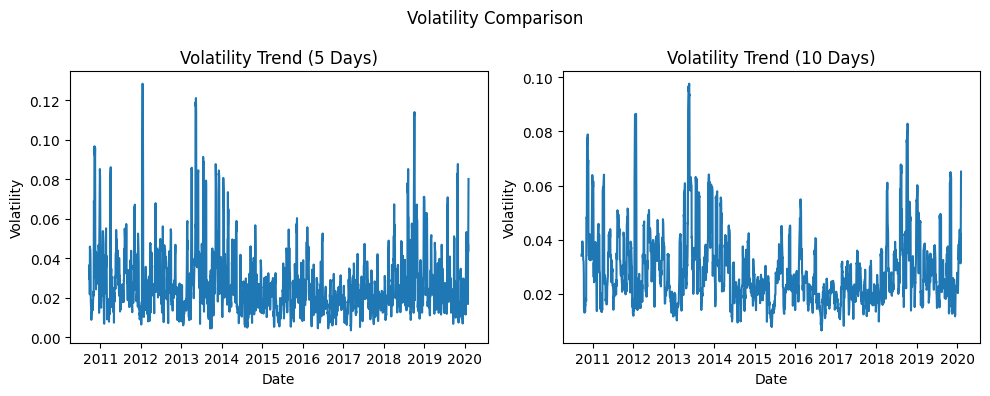

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1
axs[0].plot(df["Date"], df["Volatility_5"])
axs[0].set_title("Volatility Trend (5 Days)")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Volatility")

# Plot 2
axs[1].plot(df["Date"], df["Volatility_10"])
axs[1].set_title("Volatility Trend (10 Days)")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Volatility")

# Overall title
fig.suptitle("Volatility Comparison")

plt.tight_layout()
plt.show()

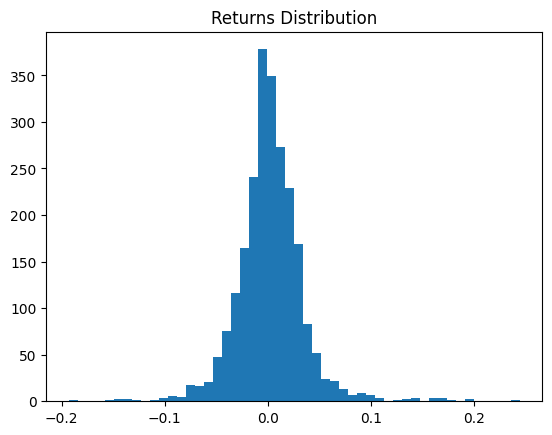

In [131]:
plt.hist(df["Returns"], bins=50)
plt.title("Returns Distribution")
plt.show()

<Axes: >

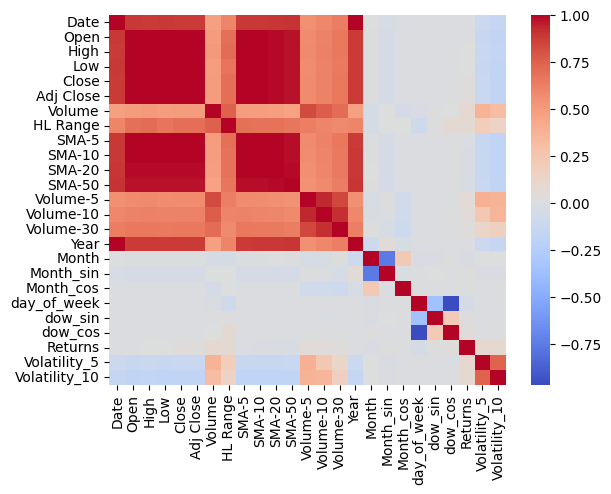

In [132]:

sns.heatmap(df.corr(), cmap="coolwarm")

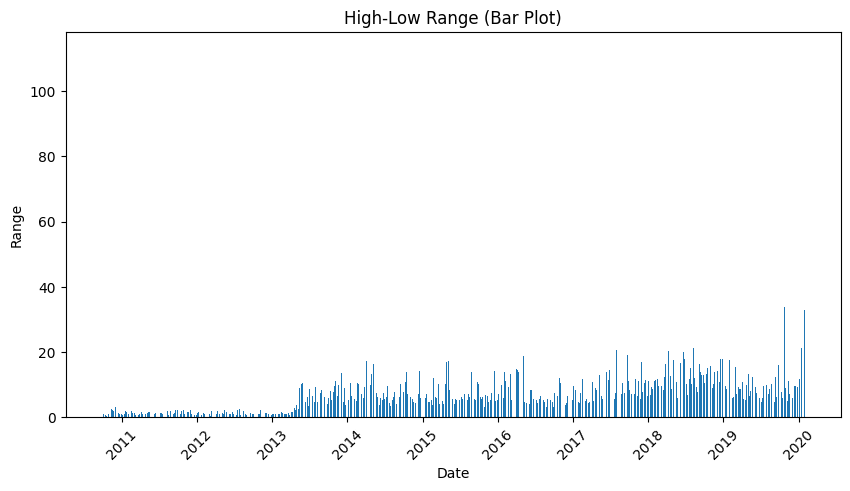

In [143]:
plt.figure(figsize=(10,5))

plt.bar(df["Date"], df["High"] - df["Low"])

plt.title("High-Low Range (Bar Plot)")
plt.xlabel("Date")
plt.ylabel("Range")
plt.xticks(rotation=45)

plt.show()

In [16]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'HL Range', 'SMA-5', 'SMA-10', 'SMA-20', 'SMA-50', 'Volume-5',
       'Volume-10', 'Volume-30', 'Year', 'Month', 'Month_sin', 'Month_cos',
       'day_of_week', 'dow_sin', 'dow_cos', 'Returns', 'Volatility_5',
       'Volatility_10'],
      dtype='str')

In [20]:
df.drop(columns=["Close"])

,Date,Open,High,Low,Adj Close,Volume,HL Range,SMA-5,SMA-10,SMA-20,...,Year,Month,Month_sin,Month_cos,day_of_week,dow_sin,dow_cos,Returns,Volatility_5,Volatility_10
49,2010-09-08,20.660000,20.950001,20.600000,20.900000,288400,0.350001,20.800000,20.270000,19.522000,...,2010,9,-1.000000,-1.836970e-16,2,0.974928,-0.222521,0.017527,0.028346,0.024368
50,2010-09-09,21.000000,21.049999,20.690001,20.709999,376200,0.359998,20.852000,20.351000,19.662500,...,2010,9,-1.000000,-1.836970e-16,3,0.433884,-0.900969,-0.009091,0.021389,0.022829
51,2010-09-10,20.750000,20.930000,19.760000,20.170000,386600,1.170000,20.674000,20.393000,19.791000,...,2010,9,-1.000000,-1.836970e-16,4,-0.433884,-0.900969,-0.026074,0.018016,0.024576
52,2010-09-13,20.889999,20.900000,20.500000,20.719999,360800,0.400000,20.608000,20.495000,19.911000,...,2010,9,-1.000000,-1.836970e-16,0,0.000000,1.000000,0.027268,0.024278,0.025696
53,2010-09-14,20.540001,21.600000,20.530001,21.120001,654700,1.069999,20.724000,20.620000,20.028000,...,2010,9,-1.000000,-1.836970e-16,1,0.781831,0.623490,0.019305,0.022464,0.026066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,11788500,18.729981,566.300012,545.911005,503.125003,...,2020,1,0.500000,8.660254e-01,1,0.781831,0.623490,0.015913,0.022303,0.031282
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,17801500,22.369995,568.586011,550.218005,511.439502,...,2020,1,0.500000,8.660254e-01,2,0.974928,-0.222521,0.024854,0.016733,0.031280
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,29005700,32.880005,582.308008,562.449005,522.563503,...,2020,1,0.500000,8.660254e-01,3,0.433884,-0.900969,0.102962,0.047332,0.039299
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,15719300,20.479980,599.458008,576.157007,533.579002,...,2020,1,0.500000,8.660254e-01,4,-0.433884,-0.900969,0.015231,0.043393,0.037826


In [46]:

corr_matrix = df.corr().abs()

# remove highly correlated features (>0.9)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

data = df.drop(columns=to_drop)

In [49]:
data["SMA-10"]=df["Close"].rolling(window=10).mean()
data["Adj Close"]=df["Adj Close"]

data.dropna(inplace=True)

In [55]:
data.drop(columns=["Date"],inplace=True)

In [57]:
features=list(data.columns)

In [58]:
dataset=data[features].values
target=data["Adj Close"].values

In [31]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error,mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [61]:
dataset_scaler=MinMaxScaler(feature_range=(0,1))
dataset_scaled=dataset_scaler.fit_transform(dataset)

In [62]:
target_scaler=MinMaxScaler(feature_range=(0,1))
target_scaled=target_scaler.fit_transform(target.reshape(-1,1))

In [63]:
lookback=20
X, y = [], []
for i in range(len(dataset_scaled) - lookback):
    X.append(dataset_scaled[i:i+lookback])
    y.append(target_scaled[i+lookback])
X = np.array(X)
y = np.array(y)    

In [64]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
    
X_train = X[:train_size]
y_train = y[:train_size]
    
X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]
    
X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [65]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((1636, 20, 14), (1636, 1), (350, 20, 14), (350, 1), (352, 20, 14), (352, 1))

In [67]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 20, 64)            20224     
                                                                 
 dropout_2 (Dropout)         (None, 20, 64)            0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 32673 (127.63 KB)
Trainable params: 32673 (127.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [68]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/25
52/52 [==============================] - 2s 11ms/step - loss: 0.0039 - mae: 0.0466 - val_loss: 8.5542e-04 - val_mae: 0.0231
Epoch 2/25
52/52 [==============================] - 0s 6ms/step - loss: 0.0015 - mae: 0.0303 - val_loss: 8.0171e-04 - val_mae: 0.0216
Epoch 3/25
52/52 [==============================] - 0s 6ms/step - loss: 0.0011 - mae: 0.0258 - val_loss: 7.9875e-04 - val_mae: 0.0219
Epoch 4/25
52/52 [==============================] - 0s 6ms/step - loss: 9.8431e-04 - mae: 0.0243 - val_loss: 0.0016 - val_mae: 0.0328
Epoch 5/25
52/52 [==============================] - 0s 6ms/step - loss: 9.1360e-04 - mae: 0.0227 - val_loss: 0.0010 - val_mae: 0.0249
Epoch 6/25
52/52 [==============================] - 0s 6ms/step - loss: 8.6965e-04 - mae: 0.0225 - val_loss: 0.0018 - val_mae: 0.0362
Epoch 7/25
52/52 [==============================] - 0s 6ms/step - loss: 7.1269e-04 - mae: 0.0202 - val_loss: 8.8815e-04 - val_mae: 0.0228
Epoch 8/25
52/52 [==============================] - 0s 7m

In [69]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

11/11 [==============================] - 0s 2ms/step - loss: 0.0026 - mae: 0.0330
Test Loss: 0.002582613378763199
Test MAE: 0.03300490602850914


In [70]:
y_pred = model.predict(X_test)

11/11 [==============================] - 0s 2ms/step


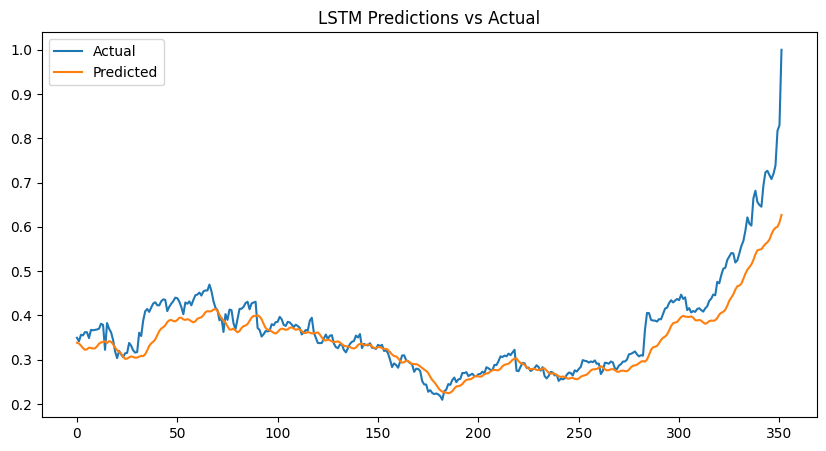

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("LSTM Predictions vs Actual")
plt.legend()
plt.show()

In [74]:
# create dummy array to inverse scale


y_pred_actual = target_scaler.inverse_transform(y_pred)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1,1))

In [76]:

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 38.645124808840166
MAE: 25.098256550506594


In [77]:
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100
print("MAPE:", mape)

MAPE: 7.259926579616613


In [80]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam

def build_model(hp):
    model = Sequential()

    # Tune number of units
    units = hp.Int("units", min_value=32, max_value=128, step=32)

    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    
    # Tune dropout
    dropout_rate = hp.Float("dropout", 0.1, 0.5, step=0.1)
    model.add(Dropout(dropout_rate))

    # Second LSTM layer
    model.add(LSTM(units // 2))
    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    # Tune learning rate
    lr = hp.Choice("learning_rate", [0.001, 0.0005, 0.0001])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [81]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,   # number of different models to try
    executions_per_trial=1,
    directory="lstm_tuning",
    project_name="stock_prediction"
)

In [82]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

In [83]:
tuner.search(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Trial 10 Complete [00h 00m 06s]
val_loss: 0.0007890955894254148

Best val_loss So Far: 0.00046817518887110054
Total elapsed time: 00h 01m 09s


In [84]:
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best Units:", best_hps.get("units"))
print("Best Dropout:", best_hps.get("dropout"))
print("Best Learning Rate:", best_hps.get("learning_rate"))

Best Units: 96
Best Dropout: 0.1
Best Learning Rate: 0.001


In [85]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/30
52/52 [==============================] - 2s 13ms/step - loss: 0.0066 - mae: 0.0536 - val_loss: 0.0014 - val_mae: 0.0316
Epoch 2/30
52/52 [==============================] - 0s 9ms/step - loss: 8.3220e-04 - mae: 0.0224 - val_loss: 9.6155e-04 - val_mae: 0.0250
Epoch 3/30
52/52 [==============================] - 0s 9ms/step - loss: 7.2981e-04 - mae: 0.0210 - val_loss: 6.3479e-04 - val_mae: 0.0193
Epoch 4/30
52/52 [==============================] - 0s 9ms/step - loss: 5.8927e-04 - mae: 0.0189 - val_loss: 9.9285e-04 - val_mae: 0.0250
Epoch 5/30
52/52 [==============================] - 0s 9ms/step - loss: 5.0941e-04 - mae: 0.0177 - val_loss: 6.5676e-04 - val_mae: 0.0195
Epoch 6/30
52/52 [==============================] - 0s 9ms/step - loss: 4.7678e-04 - mae: 0.0168 - val_loss: 0.0010 - val_mae: 0.0257
Epoch 7/30
52/52 [==============================] - 0s 9ms/step - loss: 4.3161e-04 - mae: 0.0161 - val_loss: 0.0011 - val_mae: 0.0270
Epoch 8/30
52/52 [==============================]

In [86]:
test_loss, test_mae = best_model.evaluate(X_test, y_test)
print("Test MAE:", test_mae)

11/11 [==============================] - 0s 3ms/step - loss: 0.0020 - mae: 0.0298
Test MAE: 0.02981281466782093


In [87]:
y_pred=best_model.predict(X_test)


11/11 [==============================] - 0s 3ms/step


In [88]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.04525360893191083
MAE: 0.02981281705741732


In [89]:
mape=mean_absolute_percentage_error(y_test, y_pred)
mape

0.0730393422726182

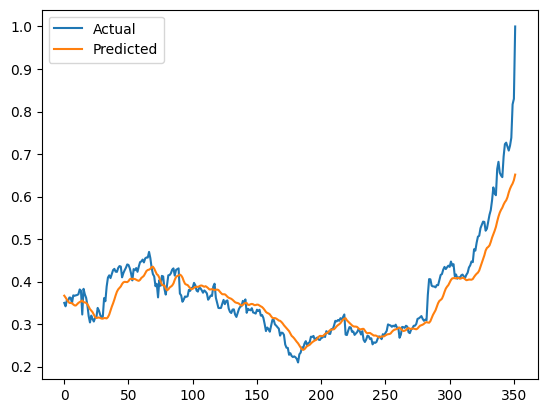

In [90]:
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

In [94]:
best_model.save("best_lstm_model")

INFO:tensorflow:Assets written to: best_lstm_model/assets


INFO:tensorflow:Assets written to: best_lstm_model/assets


In [ ]:
import joblib

joblib.dump(dataset_scaler, "dataset_scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")


['target_scaler.pkl']

In [96]:
joblib.dump(features,"features.pkl")

['features.pkl']

In [ ]:
best_model.save("best_lstm_model.h5")